# Understanding the Options Pricing Project — from zero

This notebook teaches you **everything you need to understand this project**, assuming
you know *no* computational finance. By the end you'll understand every concept the code
relies on, and you'll be able to explain the project confidently in an interview.

We'll go in this order:

1. **What an option is** — calls, puts, strike, expiry, premium
2. **Payoffs** — what you actually get paid, and "intrinsic vs. time value"
3. **Moneyness** — ITM / ATM / OTM
4. **The pricing problem** — what does "fair value" even mean?
5. **Black-Scholes** — the inputs, the intuition, the formula
6. **Volatility** — the one input you can't look up, and why it's special
7. **Implied volatility** — *inverting* the model (the heart of this project)
8. **The volatility smile / skew** — the market-implied information we surface
9. **The Greeks** — sensitivities/risk measures
10. **Walking through the actual code**, module by module, running it live

> **How to use this notebook:** run the cells top to bottom. Cells that hit the internet
> (live option chains) are clearly marked — skip them if you're offline; everything else
> works without a network.

In [3]:
# Setup. We import from the project's own package so this notebook teaches the
# *actual* code, not a parallel copy.
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt

from optvol.pricing.black_scholes import bs_price, bs_greeks
from optvol.pricing.implied_vol import implied_vol

print("Imports OK — we'll use these throughout.")

Imports OK — we'll use these throughout.


## 1. What is an option?

An **option** is a contract that gives you the *right, but not the obligation*, to buy or
sell a stock at a fixed price, on or before a fixed date.

Two types:

- **Call option** — the right to **buy** the stock at a fixed price.
- **Put option** — the right to **sell** the stock at a fixed price.

Key vocabulary (memorize these — the whole project is built on them):

| Term | Symbol | Meaning |
|---|---|---|
| **Underlying / spot** | `S` | The current price of the stock the option is on |
| **Strike** | `K` | The fixed price you're allowed to buy/sell at |
| **Expiry / maturity** | `T` | When the option expires (we measure it in **years from now**) |
| **Premium** | — | The price you pay *today* to own the option |

**A concrete example.** Apple trades at \$200 today (`S = 200`). You buy a **call** with
strike `K = 210` expiring in 3 months. You've bought the right to buy Apple at \$210 any
time in the next 3 months.

- If Apple jumps to \$250, you exercise: buy at \$210, it's worth \$250 → you made \$40 per share.
- If Apple stays at \$200, you just don't exercise. The right to buy at \$210 is worthless
  (why buy at \$210 when the market is \$200?). You lose only the premium you paid.

That asymmetry — **unlimited upside, capped downside (the premium)** — is the entire
point of options, and it's why they're not free.

## 2. Payoffs: what the option is worth *at expiry*

At expiry, an option's value is simple and mechanical — there's no more uncertainty left,
so it's worth exactly the profit from exercising (or zero):

$$\text{Call payoff} = \max(S - K,\ 0) \qquad \text{Put payoff} = \max(K - S,\ 0)$$

A call pays off when the stock ends **above** the strike; a put pays off when it ends
**below**. The `max(..., 0)` encodes "you'd never exercise at a loss — you'd just walk away."

Let's plot these famous "hockey stick" diagrams.

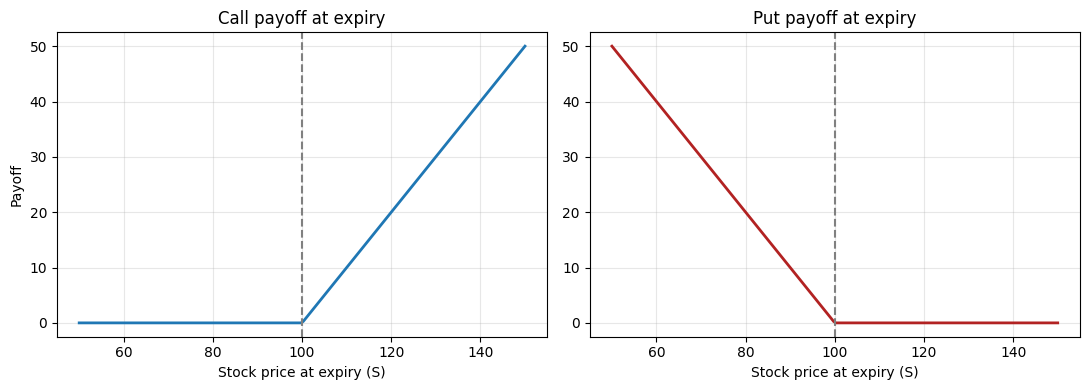

The 'kink' is at the strike K = 100


In [4]:
K = 100  # strike
S_range = np.linspace(50, 150, 200)

call_payoff = np.maximum(S_range - K, 0)
put_payoff  = np.maximum(K - S_range, 0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(S_range, call_payoff, lw=2)
ax[0].axvline(K, ls="--", color="gray"); ax[0].set_title("Call payoff at expiry")
ax[0].set_xlabel("Stock price at expiry (S)"); ax[0].set_ylabel("Payoff")
ax[1].plot(S_range, put_payoff, lw=2, color="firebrick")
ax[1].axvline(K, ls="--", color="gray"); ax[1].set_title("Put payoff at expiry")
ax[1].set_xlabel("Stock price at expiry (S)")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("The 'kink' is at the strike K =", K)

### Intrinsic value vs. time value

That payoff formula is the value *at expiry*. **Before** expiry an option is worth **more**
than that, because the stock could still move in your favor. We split the premium into:

- **Intrinsic value** — what you'd get if it expired right now: `max(S - K, 0)` for a call.
- **Time value** — the *extra* you pay for the chance the stock moves further your way
  before expiry. More time and more uncertainty → more time value.

> **Premium = Intrinsic value + Time value.**
> Pricing an option is really about pricing the *time value* — the intrinsic part is obvious.
> This is exactly what Black-Scholes computes.

## 3. Moneyness: ITM / ATM / OTM

"Moneyness" describes where the strike sits relative to the current stock price. You'll see
these three acronyms constantly (they're in the code as filters):

| Term | Call | Put |
|---|---|---|
| **ITM** (in-the-money) — has intrinsic value | `S > K` | `S < K` |
| **ATM** (at-the-money) — strike ≈ spot | `S ≈ K` | `S ≈ K` |
| **OTM** (out-of-the-money) — no intrinsic value, pure time value | `S < K` | `S > K` |

The code measures moneyness as the ratio `K / S` (1.0 = exactly at-the-money).

**Why it matters for us:** OTM options are *all time value*, which makes them the most
sensitive to — and informative about — volatility. That's why, later, the project builds the
volatility surface from **OTM options only**. Deep ITM options are mostly intrinsic value and
their quotes are stale and uninformative.

## 4. The pricing problem

Here's the real question the project answers: **what is the fair premium for an option
today, before expiry?**

Intrinsic value is easy. The hard part is the time value — pricing the *uncertainty*.
Intuitively the premium should depend on:

- How far the strike is from today's price (`S` vs `K`)
- How long until expiry (`T`) — more time = more chance to move
- **How volatile the stock is** (`σ`, "sigma") — a wild stock is more likely to swing past
  the strike, so its options are worth more
- The risk-free interest rate (`r`) — money has time value
- Dividends (`q`) — paying dividends lowers the stock, which affects calls vs puts

In **1973, Black, Scholes, and Merton** found a formula that turns those inputs into a single
fair price, under some idealized assumptions. It won the Nobel Prize and it's the foundation
of this project.

## 5. Black-Scholes

### The inputs (this is the whole API of `bs_price`)

| Input | Code | Plain English |
|---|---|---|
| `S` | spot | current stock price |
| `K` | strike | the agreed buy/sell price |
| `T` | time | years until expiry (e.g. 0.25 = 3 months) |
| `r` | rate | risk-free interest rate (e.g. T-bill yield) |
| `σ` | sigma | **volatility** — how much the stock wiggles, annualized |
| `q` | div yield | dividend yield of the stock |

### The formula

For a **call**:

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$

where

$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

Don't be intimidated — here's the intuition, piece by piece:

- $N(\cdot)$ is the **normal CDF** — "the probability a bell-curve random variable is below
  this value." It always returns a number between 0 and 1.
- $N(d_2)$ ≈ the (risk-adjusted) **probability the option finishes in-the-money**.
- $K e^{-rT}$ is the strike **discounted to today** (a dollar later is worth less than a
  dollar now — that's the $e^{-rT}$).
- So $K e^{-rT} N(d_2)$ ≈ "what you'll pay for the stock, times the chance you actually buy it."
- $S e^{-qT} N(d_1)$ ≈ "the value of the stock you'll receive, times its risk-adjusted chance."
- **Call price = (expected value of what you get) − (expected cost of what you pay).** That's it.

The put formula is the mirror image. Let's just *use* the code.

In [15]:
# Price a 3-month at-the-money call and put.
S, K, T, r, sigma, q = 100.0, 100.0, 0.25, 0.04, 0.20, 0.0

call = bs_price(S, K, T, r, sigma, "call", q)
put  = bs_price(S, K, T, r, sigma, "put",  q)
print(f"3-month ATM call fair value: {call:.2f}")
print(f"3-month ATM put  fair value: {put:.2f}")

# Sanity check #1: an option you can exercise now is worth at LEAST its intrinsic value.
print("\nDeep in-the-money call (S=130, K=100):")
itm = bs_price(130, 100, T, r, sigma, "call", q)
print(f"  price = {itm:.2f}, intrinsic = {130-100} -> price >= intrinsic? {itm >= 30}")

3-month ATM call fair value: 4.49
3-month ATM put  fair value: 3.49

Deep in-the-money call (S=130, K=100):
  price = 31.01, intrinsic = 30 -> price >= intrinsic? True


### How each input pushes the price around

The best way to build intuition is to wiggle one input at a time and watch the price move.
Notice especially how **more volatility always makes the option more valuable** — that
monotonic relationship is what lets us *invert* the formula later.

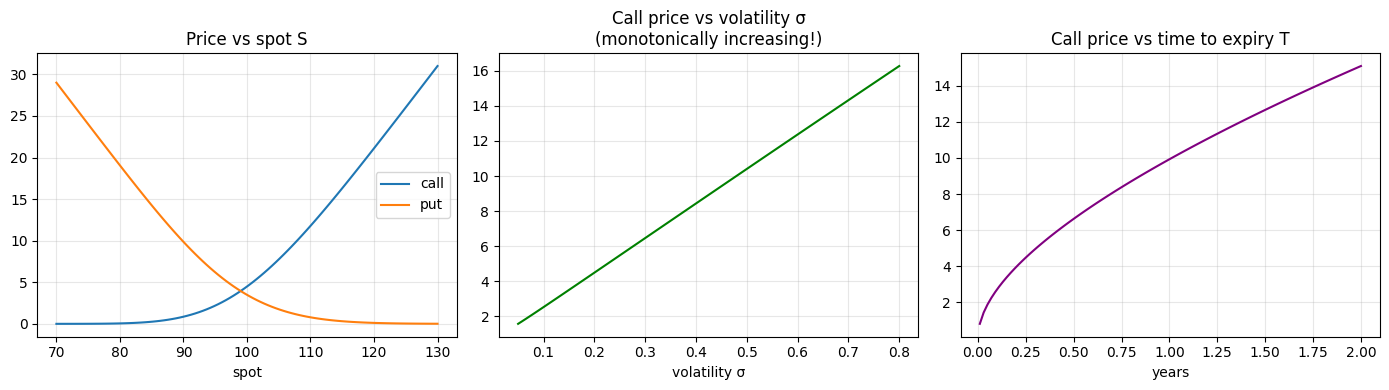

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# (a) price vs spot
spots = np.linspace(70, 130, 100)
ax[0].plot(spots, bs_price(spots, K, T, r, sigma, "call", q), label="call")
ax[0].plot(spots, bs_price(spots, K, T, r, sigma, "put",  q), label="put")
ax[0].set_title("Price vs spot S"); ax[0].set_xlabel("spot"); ax[0].legend()

# (b) price vs volatility  <-- the key one
vols = np.linspace(0.05, 0.8, 100)
ax[1].plot(vols, bs_price(S, K, T, r, vols, "call", q), color="green")
ax[1].set_title("Call price vs volatility σ\n(monotonically increasing!)")
ax[1].set_xlabel("volatility σ")

# (c) price vs time to expiry
times = np.linspace(0.01, 2.0, 100)
ax[2].plot(times, bs_price(S, K, times, r, sigma, "call", q), color="purple")
ax[2].set_title("Call price vs time to expiry T"); ax[2].set_xlabel("years")

for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Volatility — the special input

Look back at the Black-Scholes inputs. Five of the six are **observable** — you can look them
up right now:

- `S` spot → on any quote screen
- `K`, `T` → written in the contract
- `r` → the Treasury-bill yield
- `q` → the stock's dividend yield

But **volatility `σ` is not observable.** It's *how much the stock will wiggle in the future* —
nobody knows it. It's the one number you have to estimate or infer.

This is the crux of everything. Because volatility is the only unknown, and because the price
increases smoothly with volatility (that green chart above), we can flip the problem around.

## 7. Implied volatility — *inverting* the model (the heart of this project)

So far we've gone **forward**: inputs (including a guessed σ) → price.

But the market already tells us the **price** of every option (people are trading them right
now). So we can run Black-Scholes **backward**:

> Given the market price, **what volatility would make Black-Scholes output that exact price?**

That number is the **implied volatility (IV)** — the volatility "implied" by the market price.
It's the market's collective forecast of how volatile the stock will be.

### The mistake this project was built to fix

The original version of this project did something subtly wrong: it took the market's *quoted*
IV and fed it **into** Black-Scholes to get a price. That's **circular** — IV is *defined* as
the number that reproduces the market price, so you just get the market price back. You learn
nothing.

The correct move — what the project now does — is the **inversion**: take the observed market
price and **solve for** the IV. There's no algebraic formula for this (you can't isolate σ in
that equation), so we solve it numerically. Let's prove it round-trips.

In [7]:
# Forward: pick a "true" volatility, compute the price.
true_sigma = 0.35
price = bs_price(S, K, T, r, true_sigma, "call", q)
print(f"With sigma = {true_sigma}, Black-Scholes price = {price:.4f}")

# Backward: pretend we only know that price, and recover the volatility.
recovered = implied_vol(price, S, K, T, r, "call", q)
print(f"implied_vol() recovers sigma = {recovered:.4f}")
print(f"Match? {np.isclose(recovered, true_sigma)}")

With sigma = 0.35, Black-Scholes price = 7.4467
implied_vol() recovers sigma = 0.3500
Match? True


### How the solver finds it (intuition, not heavy math)

We're looking for the σ where `bs_price(σ) - market_price = 0` — a **root-finding** problem.
Picture the green curve from earlier (price rising with σ): we want the σ where that curve
hits the market price. The project uses two classic techniques:

- **Newton-Raphson** — start at a guess, use the *slope* (that slope is "vega", a Greek we'll
  meet next) to jump toward the answer, repeat. Very fast when it behaves.
- **Brent's method** — a robust fallback that *brackets* the answer between two bounds and
  can't diverge. Used when Newton wanders off.

The solver also returns `None` when **no** volatility can reproduce the price (e.g. a stale
quote that violates basic no-arbitrage bounds) — important, because real market data is messy.

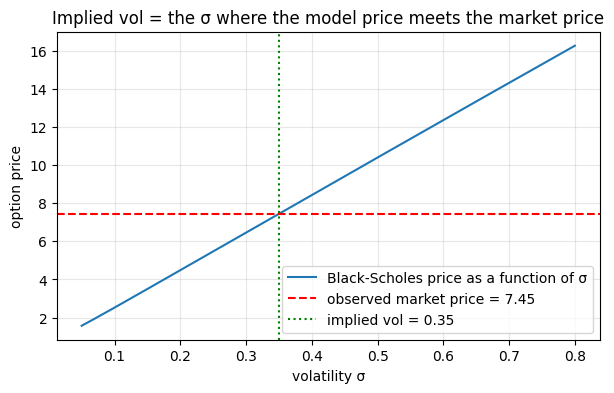

In [8]:
# Visualize the root-finding: where does the price curve cross the market price?
market_price = price  # from the cell above
vols = np.linspace(0.05, 0.8, 200)
prices = bs_price(S, K, T, r, vols, "call", q)

plt.figure(figsize=(7,4))
plt.plot(vols, prices, label="Black-Scholes price as a function of σ")
plt.axhline(market_price, color="red", ls="--", label=f"observed market price = {market_price:.2f}")
plt.axvline(recovered, color="green", ls=":", label=f"implied vol = {recovered:.2f}")
plt.xlabel("volatility σ"); plt.ylabel("option price")
plt.title("Implied vol = the σ where the model price meets the market price")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. The volatility smile / skew

Here's where it gets interesting — and where the project surfaces *real market information*.

Black-Scholes **assumes a single, constant volatility** for a stock. If that were true, every
option on the same stock (every strike) would imply the **same** IV. A flat line.

**It isn't true.** When you solve IV for every strike, you get a **curve**, not a line:

- For equity indexes like SPY, IV is *higher* for low strikes (OTM puts) and slopes downward —
  this is the **volatility skew**. It exists because investors pay up for crash protection
  (OTM puts), bidding their prices — and therefore implied vols — higher.
- For many stocks the curve turns up at both ends — the **volatility smile**.

The shape is the market saying *"we don't believe Black-Scholes' constant-volatility
assumption — extreme moves are more likely than the simple model thinks."* **Surfacing that
shape from live data is the whole thesis of the project.** Let's build one synthetically first
so the idea is crystal clear, then do it on real data.

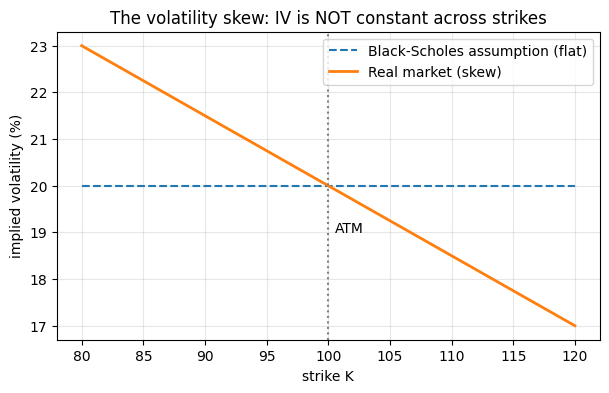

In [ ]:
# Synthetic illustration: a flat-vol world vs. the real skewed world.
strikes = np.linspace(80, 120, 40)
flat = np.full_like(strikes, 0.20)                      # what Black-Scholes assumes
skew = 0.20 + 0.0015 * (100 - strikes)                  # real markets: puts (low K) bid up

plt.figure(figsize=(7,4))
plt.plot(strikes, flat*100, "--", label="Black-Scholes assumption (flat)")
plt.plot(strikes, skew*100, lw=2, label="Real market (skew)")
plt.axvline(100, color="gray", ls=":"); plt.text(100.5, 19, "ATM")
plt.xlabel("strike K"); plt.ylabel("implied volatility (%)")
plt.title("The volatility skew: IV is NOT constant across strikes")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 9. The Greeks — sensitivities (risk measures)

The **Greeks** measure how the option's price responds to each input changing. Traders use them
to understand and hedge risk. The project computes them analytically in `bs_greeks`.

| Greek | Measures sensitivity to… | Plain English |
|---|---|---|
| **Delta** (Δ) | spot `S` | How much the option moves per \$1 move in the stock |
| **Gamma** (Γ) | spot, again | How fast Delta itself changes (curvature) |
| **Vega** (ν) | volatility `σ` | How much the option moves per 1 vol-point change |
| **Theta** (Θ) | time `T` | How much value decays per day as expiry approaches |
| **Rho** (ρ) | rate `r` | Sensitivity to interest rates |

Two connections to what we just learned:

- **Vega** is exactly the *slope* the Newton solver uses to find implied vol. Where vega is
  tiny (deep ITM options), the inversion is unreliable — another reason the project uses OTM
  options for the surface.
- **Delta** is roughly the probability the option finishes in-the-money, and it's how you'd
  hedge: a Delta of 0.6 means hold 0.6 shares to offset one option.

Greeks for a 3-month ATM call (S=K=100, σ=20%):

   price: +4.4852
   delta: +0.5596
   gamma: +0.0394
    vega: +0.1972
   theta: -0.0273
     rho: +0.1287


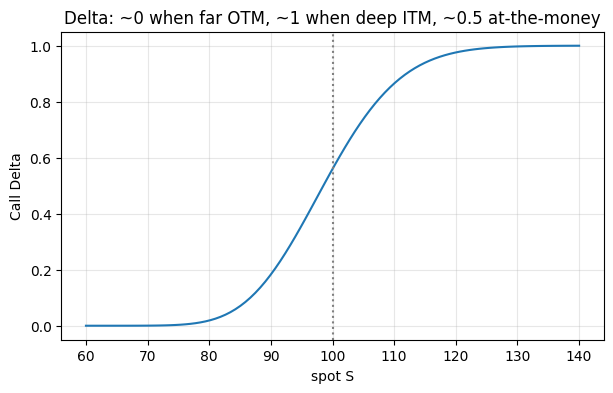

In [10]:
g = bs_greeks(S, K, T, r, sigma, "call", q)
print("Greeks for a 3-month ATM call (S=K=100, σ=20%):\n")
for name, val in g.items():
    print(f"  {name:>6}: {val:+.4f}")

# Watch Delta sweep from 0 (deep OTM) to 1 (deep ITM) — the 'probability of finishing ITM' shape
spots = np.linspace(60, 140, 100)
deltas = bs_greeks(spots, K, T, r, sigma, "call", q)["delta"]
plt.figure(figsize=(7,4))
plt.plot(spots, deltas)
plt.axvline(K, ls=":", color="gray"); plt.xlabel("spot S"); plt.ylabel("Call Delta")
plt.title("Delta: ~0 when far OTM, ~1 when deep ITM, ~0.5 at-the-money")
plt.grid(alpha=0.3); plt.show()

## 10. Walking through the actual code

Now that you have the concepts, here's how the repo is organized and what each piece does.

```
optvol/
  data.py                  pull + CLEAN live option chains; get spot, rate, dividends
  analyze.py               solve IV for every contract, add Greeks, build divergence view
  pricing/
    black_scholes.py       the price formula + analytic Greeks (we used these above)
    implied_vol.py         the Newton/Brent inversion (we used this above)
cli.py                     command-line entry point
tests/                     proves parity, IV round-trip, and Greek correctness
```

**The data flow, end to end:**

1. `data.load_chain("AAPL")` pulls the live option chain, the spot price, a real risk-free
   rate (13-week T-bill `^IRX`), and the dividend yield — then **cleans** the chain (drops
   contracts with no real two-sided market, crossed quotes, blown-out spreads, dead liquidity).
   Real data is noisy; this step is essential.
2. `analyze.enrich_chain(snap)` runs the **inversion** on every surviving contract — solving
   each one's implied vol from its market mid price — then attaches Greeks and computes the
   **divergence**: it prices every option at a *single* ATM volatility (what a naive
   Black-Scholes user would do) and measures the gap to the real market price. That gap **is**
   the smile/skew — the information a one-number model throws away.

Let's run the project's own pricing core the way `analyze.py` does, on a small made-up chain
(no network needed):

In [11]:
# Mimic what analyze.py does, on a synthetic chain, so you can see the logic with no network.
spot = 100.0
chain = [  # (option_type, strike, pretend market mid price)
    ("put",  90,  1.10),
    ("put",  95,  2.30),
    ("call", 100, 4.10),
    ("call", 105, 2.20),
    ("call", 110, 1.05),
]

print(f"Spot = {spot}\n")
print(f"{'type':>5} {'strike':>7} {'mkt price':>10} {'implied vol':>12}")
ivs = []
for opt, strike, mid in chain:
    iv = implied_vol(mid, spot, strike, T=0.25, r=0.04, option_type=opt, q=0.0)
    ivs.append((strike, iv))
    print(f"{opt:>5} {strike:>7} {mid:>10.2f} {iv:>11.1%}")

print("\nNotice the implied vols are NOT all equal across strikes -> that's the smile/skew,")
print("recovered purely by inverting the model against each market price.")

Spot = 100.0

 type  strike  mkt price  implied vol
  put      90       1.10       24.7%
  put      95       2.30       24.2%
 call     100       4.10       18.0%
 call     105       2.20       19.0%
 call     110       1.05       19.4%

Notice the implied vols are NOT all equal across strikes -> that's the smile/skew,
recovered purely by inverting the model against each market price.


### Doing it on **live** data (needs internet)

This is the real thing — the same functions, but against an actual option chain pulled live.
Run it during/near US market hours for the freshest quotes.

In [12]:
# LIVE DATA CELL — requires internet. Skip if offline.
from optvol.data import load_chain
from optvol.analyze import enrich_chain, summary

snap = load_chain("SPY")          # nearest tradeable expiry, cleaned
df = enrich_chain(snap)           # solve IV per contract + Greeks + divergence
print(summary(df, snap))

SPY  spot=754.68  expiry=2026-06-22  T=0.019y  r=3.62%  q=0.98%
ATM implied vol (solved): 9.57%
Priceable contracts: 162

Largest flat-vol model vs market divergences across OTM contracts
(the smile a single vol misses):
   put K=753.00   mkt=   4.94  flat-BS=   3.04  diff=  -1.90  IV=14.2%
   put K=752.00   mkt=   4.53  flat-BS=   2.64  diff=  -1.89  IV=14.3%
   put K=750.00   mkt=   3.80  flat-BS=   1.95  diff=  -1.86  IV=14.4%
   put K=749.00   mkt=   3.48  flat-BS=   1.66  diff=  -1.82  IV=14.5%
   put K=751.00   mkt=   4.09  flat-BS=   2.27  diff=  -1.82  IV=14.2%
   put K=754.00   mkt=   5.27  flat-BS=   3.48  diff=  -1.79  IV=13.9%


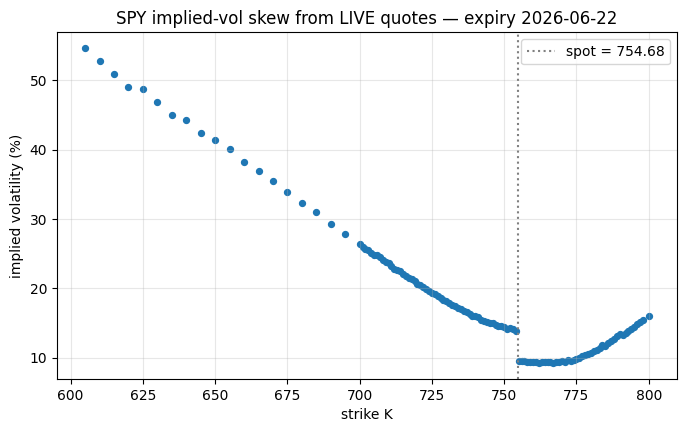

In [13]:
# Plot the REAL volatility skew you just computed from live quotes (OTM contracts only).
otm = df[df["is_otm"]].sort_values("strike")
plt.figure(figsize=(8,4.5))
plt.scatter(otm["strike"], otm["iv_solved"]*100, s=18)
plt.axvline(snap.spot, color="gray", ls=":", label=f"spot = {snap.spot:.2f}")
plt.xlabel("strike K"); plt.ylabel("implied volatility (%)")
plt.title(f"{snap.symbol} implied-vol skew from LIVE quotes — expiry {snap.expiry}")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Recap — the one-paragraph version you can say out loud

> An option is the right to buy (call) or sell (put) a stock at a fixed **strike** by a fixed
> **expiry**. **Black-Scholes** turns six inputs into a fair price, but five are observable and
> only **volatility** is not. Because the price rises smoothly with volatility, you can run the
> model **backward**: given the market price, solve for the **implied volatility**. Doing this
> across every strike reveals the **volatility skew** — a curve, not the flat line Black-Scholes
> assumes — which is the market pricing in fat tails and crash risk. This project pulls **live**
> option chains, cleans the noisy quotes, **inverts** Black-Scholes to recover each contract's
> implied vol, computes the **Greeks**, and quantifies how far a naive single-volatility model
> **diverges** from the real market — i.e. it surfaces market-implied information instead of just
> plugging into a formula.

### Where to go next
- Open `optvol/pricing/black_scholes.py` and match each line to the formula in Section 5.
- Open `optvol/pricing/implied_vol.py` and find the Newton step and the Brent fallback from
  Section 7.
- Run `python cli.py AAPL --show-drops` in a terminal to see the data-cleaning report.
- The README's roadmap shows the next phases: a 3D vol **surface**, Monte Carlo, and an ML/LLM
  layer.